# 실습해보기

In [ ]:
# 데이터 불러오기
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()



```python
(train_input, train_target), (test_input, test_target)

```
-> 한번에 4개 값을 받아서 두 묶음으로 나눈다   
-> 괄호는 데이터 묶음(튜플)을 표현



```python
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
```
<실제 반환 구조>  
-> 튜플 안에 튜플 구조

```
(
   (x_train, y_train),
   (x_test,  y_test)
)
```





In [ ]:
train_input.shape, train_target.shape, test_input.shape, test_target.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

(60000, 28, 28)
-> 60000(이미지가 6만장), 28(세로 픽셀 수), 28(가로 픽셀수)  

(60000,)  
-> 60000(정답 6만개), 쉼표 : 1차원 배열이라는 뜻  

### shape이 이렇게 생긴 이유
- 딥러닝은 '묶음 단위'로 학습 -> 여러장을 한번에 처리  
- 첫번째 숫자는 항상 개수
- 이미지는 2차원 데이터(높이x너비)

=> shape은 데이터가 몇개이고, 각 데이터가 어떤 모양인지 알려줌

In [ ]:
# 이미지의 숫자 범위를 정리ㅐ서 모델이 공부하기 쉽게 만들어주는 작업
# 원래 fashion_mnist 이미지 픽셀값은 0(완전 검정) ~ 255(완전 흰색)
# -> 이 큰 값을 정규화를 통해 0~1 사이값으로 변경 후 모델 학습 진행

# train_scaled = train_input / 255.0
# test_scaled = test_input / 255.0
import numpy as np

# 정규화를 하기 위해 학습 데이터의 평균과 분산 구하기
mean = np.mean(train_input) # 훈련 이미지 전체 픽셀의 평균값 -> 전체적으로 이 정도 밝기구나~ 가늠 가능
std  = np.std(train_input) # 픽셀 값들이 평균에서 얼마나 흩어져 있는지(표준편차) -> 작으면 값들이 비슷, 크면 밝고 어두운 차이 큼

# 데이터 정규화하기
# 0으로 나눠지는 것 (=무한대로 수렴)을 막기 위해 1e-7 더기기
train_scaled = (train_input-mean)/(std+1e-7)
test_scaled  = (test_input-mean) /(std+1e-7)


In [ ]:
# Fashion-MNIST를 다중 클래스 분류하는 Keras 신경망 예제
# 다중 클래스 분류 : 클래스가 3개 이상인 상태에서 정답인 클래스 하나 분류

from keras.layers import Flatten  # 2차원 이미지를 1차원으로 펼쳐주는 층
from keras.layers import Dense  # 완전연결층(뉴런 묶음) # Dense : 신경망 층
from keras.models import Sequential  # 층을 순서대로 쌓는 모델

model = Sequential()

model.add(Flatten(input_shape=(28,28)))  #(28,28) -> (784,) 변경 #Dense 층은 1차원 입력만 받기에 변경 필수
model.add(Dense(100, activation='relu')) # 첫번째 은닉층 # 784개의 입력을 받아서 100개의 출력으로 변환
model.add(Dense(10, activation='softmax'))  # 10개의 클래스 중 하나를 고르는 층 #softmax : 각 클래스 활률로 변환(가장 큰 값이 예측 결과)

model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'], optimizer='adam')  # 모델 컴파일(학습 규칙 정하기)

model.fit(train_scaled, train_target, validation_split=0.1, epochs = 5, verbose = 1) # 모델 학습

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7950 - loss: 0.5747 - val_accuracy: 0.8570 - val_loss: 0.3875
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8683 - loss: 0.3594 - val_accuracy: 0.8742 - val_loss: 0.3560
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8824 - loss: 0.3201 - val_accuracy: 0.8752 - val_loss: 0.3499
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8891 - loss: 0.3008 - val_accuracy: 0.8728 - val_loss: 0.3531
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8987 - loss: 0.2744 - val_accuracy: 0.8748 - val_loss: 0.3526


metrics
- 학습 중 보여줄 성적표
- accuracy : 정답률

optimizer
- 어떻게 공부할지 정하는 방법
- adam : 가장 많이 쓰이는 기본값(학습 속도 빠르고 안정적)





```python
model.fit(
    train_scaled,
    train_target,
    validation_split=0.1,
    epochs=5,
    verbose=1
)
```
train_scaled
- 입력 데이터(이미지)
- shape : (60000, 28, 28)

train_target
- 정답 라벨
- shape : (60000, )
- 값 : 0~9(인덱스 번호)
- ex) train_target[i] = 7

validation_split=0.1
- 훈련 데이터의 10%를 검증용으로 사용
- 과적합 확인용

epochs=5
- 전체 데이터를 5번 반복해서 학습

verbose=1
- 학습 로그 출력 방식
- 0 : 아무것도 안보임
- 1 : 진행바 + 결과
- 2 : 줄 단위 출력

In [ ]:
# 만든 모델의 구조를 한눈에 보여줌
# 모델에 어떤 층이 있고 각 층의 입출력 그기와 학습할 파라미터가 몇개인지 보여줌
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

**Output shape**
- ex) (None, 784)  
-> None : 데이터 개수(이미지 장수)가 아직 정해지지 않았다  
-> 학습 시 32장, 평가시 10000장 처럼 상황마다 달라짐  

**Param**
- 이 층이 학습해야할 숫자의 개수(가중치 + 편향)
- Flatten 층 : 0   
-> 단순히 펼치기만 해서 학습할 값 없음
- 첫번째 Dense 층 : 입력 784, 출력 100   
-> 가중치 : 784x100 = 78400 + 편향 100 => 78500

- 두번째 Dense층 : 입력 100, 출력 10  
-> 가중치 : 100 x 10 = 1000 + 편향 10 => 1010

**Total Params**
- 모델이 가진 전차 숫자 계수

**Trainable params**
- 학습으로 바뀌는 숫자들

**Non-trainable params**
- 고정된 값

**Optimizer params**
- 가중치를 어떻게 업데이트 할지 기억하기 위한 메모용 숫자

In [ ]:
#학습이 끝난 모델 test 데이터로 평가
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8703 - loss: 0.3666


[0.3615933358669281, 0.8725000023841858]

In [ ]:
# 모델을 구성하는 모든 설정값을 파이썬 딕셔너리 형태로 반환
model.get_config()

{'name': 'sequential_9',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 28, 28),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer_10'},
   'registered_name': None},
  {'module': 'keras.layers',
   'class_name': 'Flatten',
   'config': {'name': 'flatten_6',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'data_format': 'channels_last'},
   'registered_name': None,
   'build_config': {'input_shape': (None, 28, 28)}},
  {'module': 'keras.layers',
   'class_name': 'Dense',
   'config': {'name': 'dense_19',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'regi

# 진도 더 나가기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [ ]:
# 기존 훈련 데이터를 훈련(train) + 검증(validation) 데이터 나누기
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [ ]:
def model_fn(a_layer=None):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28, 28)))
  model.add(keras.layers.Dense(100, activation='relu'))
  if a_layer:
    model.add(a_layer)
  model.add(keras.layers.Dense(10, activation='softmax'))
  return model

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))

In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    optimizer='adam'
    )


In [ ]:
history = model.fit(train_scaled, train_target, epochs=20, verbose=2, validation_split = 0.1)
history.history.keys()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

Epoch 1/20


##콜백
-> 훈련 과정 중간에 어떤 작업을 수행하게 해주는 객체  
-> 프로그래밍에서 다른 함수의 인수로 전달되는 함수 의미  
-> fit 메서드의 callbacks=[]에 리스트로 전달하여 사용  
=> 모델이 학습하는 도중에 사람이 미리 정해둔 행동을 자동으로 실행해 주는 장치

##ModelCheckpoint 콜백(= 자동 저장 콜백)
-> 기본적으로 epoch마다 모델 저장  
-> save_best_only = True는 가장 낮은 검증 점수를 만드는 모델을 저장  
=> 학습하면서 성능이 가장 좋은 모델만 자동으로 파일을 저장해주는 기능

- 검증점수(val_loss) : 모델의 실수 정도  
  -> 예측이 정답에서 얼마나 틀렸는가  
  -> loss 값이 크면 많이 틀림, loss값이 작으면 거의 안틀림



```
# 검증 손실이 가장 낮다
# = 검증 데이터에서 가장 덜 틀렸다
# = 실전 성능이 가장 좋다
# = 성능이 가장 좋은 모델이다 ✅
```



##EarlyStopping
-> 조기 종료 콜백 필요  
-> patience = 3이면, 3번까지 연속 검증 손실 점수가 향상되지 않으면 훈련 중지  
-> restore_best_weights = True : 가장 낮은 검증 손실을 낸 모델 파라미터로 되돌림  
=> 모델 성능이 더 이상 좋아지지 않으면 시간 낭비하지 말고 학습을 자동으로 멈추는 기능

In [ ]:
# 1. model_fn 함수에 Dropout(0.3) 레이어 넣어서 모델 생성
model = model_fn(keras.layers.Dropout(0.3))
# Dropout : 학습할 때 뉴런의 30%를 랜덤으로 꺼버려서(0.3) 모델이 특정 패턴만 외우지 않게 해주는 역할(과적합 방지)

# 2. 모델 학습 방법 설정(옵티마이저, 손실함수, 평가 지표)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# optimizer : 가중치를 어떻게 업데이트할지 결정하는 알고리즘
# loss : 손실함수
# metrics=['accuracy'] : 학습 중/후에 정확도를 함께 출력

# 3. 가장 성능이 좋은 모델을 자동으로 파일로 저장하는 콜백 설정
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
# 'best_model.keras' : 모델을 저장할 파일 이름
# save_best_only=True : 검증 성능이 좋아졌을 때만 저장(최고 성능 모델)

# 4. 모델 학습 시작
model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled,val_target), callbacks=[checkpoint_cb])
# (학습용 입력 데이터, 학습용 정답 데이터, 전체 데이터 20번 반복 학습, 학습 로그 출력 모드(0: 출력 안함), 검증에 사용할 데이터(검증용 입력 데이터, 검증용 정답 데이터), 학습 중에 호출할 콜백 리스트)

In [ ]:
ls

In [ ]:
# 학습 중 ModelCheckpoint로 저장해둔 '최고 성능 모델'을 불러와 검증 데이터로 최종 성능을 다시 확인하는 코드
model = keras.models.load_model('best_model.keras')
model.evaluate(val_scaled, val_target)

위 코드 실행 시 '학습 중 가장 잘 나왔던 모델이 검증 데이터에서 실제로도 이 정도 성능을 낸다'는 공식 상대성 점검


모델 생성 후 학습 시 model.fit()에서 validation_data를 넣었는데 다시 val_scaled, val_target으로 평가하는 이유  
-> 마지막 epoch 모델이 최고 모델이라는 보장 없음  
=> ModelCheckpoint로 최고 성능 모델을 파일로 저장하고 load_model()로 그 최고 모델을 불러온 다음 evaluate(val_scaled, val_target)으로 구 최고 모델의 진짜 성능을 재확인 하는 것임  


model.evaluate(val_scaled, val_target)으로 검증 성적 확인 후 진짜 최종 성적은 model.evaluate(test_scaled, test_target)으로 확인

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled,val_target), callbacks=[checkpoint_cb, early_stopping_cb])

In [ ]:
# EarlyStopping 콜백이 '학습을 강제로 멈춘 정확한 epoch 번호'를 알려주는 속성
early_stopping_cb.stopped_epoch

###위 코드 실행 시 알 수 있는 것  

✅ 과적합이 몇 epoch쯤부터 시작됐는지 추정 가능

✅ “굳이 50 epoch까지 안 해도 됐구나”

✅ “이 모델은 대략 8~10 epoch쯤이면 충분하네”

✅ 다음 실험에서 epochs를 더 효율적으로 잡을 수 있음

### 과소적합 의심될 때 모델 키우는 순서


```
❗ 과소적합이면 →
① epoch(학습 횟수) 늘려 보고 : 학습을 너무 조금 시켜서 못 배운건지 의심
② 그래도 안 되면 노드 수 늘리고
③ 그래도 안 되면 층(레이어) 수를 늘려라 : 모델이 더 복잡한 패턴, 단계적인 특징 학습 가능
```

과소적합(Underfitting)  
: 모델이 너무 단순해 훈련 데이터도 제대로 못 맞추는 상태  

## Convolution Neural Network(CNN, 합성곱 신경망)
-> 이미지 같은 데이터를 입력받아 중요한 특징만 자동으로 뽑고 그걸로 정답을 맞히는 신경망  
-> 이미지를 윤곽 > 무늬 > 형태 순서로 인식하게 만드는 구조
- 신호의 구분, 변형, 특징 추출 같은 작업을 효과적으로 하기 위함  
- 여기서 곱해지는 값 = 필터 = 커널이라 부름

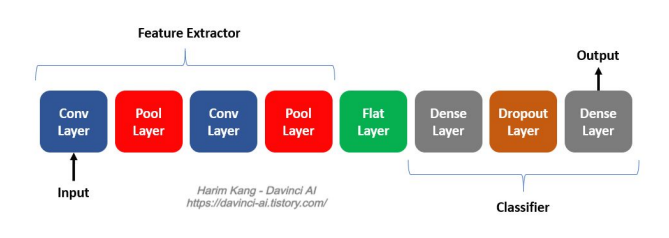

① 이미지 입력  
② Conv: 윤곽선 같은 특징 찾기  
③ Pool: 중요한 정보만 남기고 줄이기  
④ Conv: 더 복잡한 모양 찾기  
⑤ Pool: 또 압축  
⑥ Flatten: 일렬로 펼치기  
⑦ Dense: 특징 종합해서 판단  
⑧ Dropout: 외우지 못하게 방해  
⑨ Dense + Softmax: 정답 확률 출력  

!요약!  
-> CNN은 이미지에서 특징을 뽑는 Conv + Pool 부분과 그 특징으로 정답을 맞히는 Dense 부분이 합쳐진 구조



In [ ]:
# sudo 코드(가상코드)
# keras.layers.Conv2D 클래스를 사용해 만든다

# Conv2D(32,(5,5), padding='valid', input_shape(28,28,1), activation='relu')

In [ ]:
import numpy
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# 1. 모델 생성
model = Sequential()

# 2. 첫번째 합성곱(Conv2d)층
# model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(8,8,1)))
# model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(2, (3,3), padding='same', activation='relu', input_shape=(8,8,1))) # 결과 형태 대략 : (8,8,2)
model.add(MaxPooling2D(pool_size=(2,2))) # 입력 : (8,8,2)  출력 : (4,4,2)
model.add(Conv2D(3,(2,2), padding='same', activation='relu'))  # 입력(4,4,2)  출력(4,4,3)
model.add(MaxPooling2D(pool_size=(2,2)))  # 입력 : (4,4,3)  출력 : (2,2,3)
model.add(Flatten())  # 2D feature map을 1차원 벡터로 펼치기  # (2,2,3) -> 2x2x3 : 12 -> (12,) 길이의 1차원 벡터로 변환
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))



```python
model.add(Conv2D(2, (3,3), padding='same', activation='relu', input_shape=(8,8,1)))
```
- 2 -> filters = 2 : 출력 채널 개수 2개  
- (3,3) -> kernel_size : 3x3 크기의 필터(커널) 사용  
- padding='same' -> 입력과 출력의 가로/세로 크기를 같게 유지  
- activation = 'relu' : 음수는 0으로, 양수만 살려주는 활성화 함수  
- input_shape=(8,8,1) : (가로 8, 세로 8, 채널 1(흑백))인 이미지 입력



```python
model.add(MaxPooling2D(pool_size=(2,2)))
```
- pool : 중요한 정보만 남기고 줄이기  
- 2x2 영역마다 최대값을 하나만 남김 -> 가로/세로 크기를 절반으로 줄임



```python
model.add(Flatten())
```
- 2차원 feature map을 1차원 벡터로 펼치기
- ex. (가로, 세로, 채널) 형태의 3차원 데이터를 (특징 개수,) 형태의 1차원 벡터로 변환


In [ ]:
model.summary()

### feature map(특징맵)
-> 필터(커널)가 이미지 여기저기를 훑으면서 '내가 찾는 패텬이 여기 있/없다'를 표시해둔 결과 이미지  


In [ ]:
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0 # (60000,28,28) -> (60000,28,28,1)로 CNN이 요구하는 4차원 입력 형태로 맞추는 작업
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

train_scaled.shape, train_target.shape, val_scaled.shape, val_target.shape

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28,28,1)))

네가 꼭 기억해야 할 핵심 5가지

1️⃣ Conv2D

✅ 특징을 찾는다

✅ feature map을 만든다

✅ 채널 수 = filters 개수

2️⃣ MaxPooling2D

✅ 가로/세로 줄인다

✅ 중요한 특징만 남긴다

✅ 채널 수는 유지

3️⃣ feature map

✅ “특정 특징 하나만 강조된 결과 이미지”

4️⃣ Flatten

✅ CNN → 일반 신경망으로 넘기는 관문

✅ (가로×세로×채널) → 1차원 벡터

5️⃣ Dense + Softmax

✅ 최종 분류 담당

✅ 확률 출력

위 코드 실행했을 때,  
output shape : (28,28,32)

채널 수  : 필터의 개수가 32개라 채널수도 32

In [ ]:
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

In [ ]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

In [ ]:
model.summary()

In [ ]:
# CNN 학습 + 가장 좋은 모델 저장 + EarlyStopping 한번에 세팅
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only = True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target),callbacks=[checkpoint_cb, early_stopping_cb])

🔚 전체 흐름 한 번에 요약하면

1. compile  
→ 학습 규칙 설정 (Adam + sparse crossentropy + accuracy)

2. ModelCheckpoint  
→ 학습 중 가장 성능 좋은 모델을 파일로 자동 저장

3. EarlyStopping  
→ 성능이 더 좋아지지 않으면 조기 종료 + 최고 성능 가중치로 복구

4. fit(..., callbacks=[…])  
→ 실제 학습 진행  
→ 매 epoch마다:

  - train_loss / train_accuracy 측정

  - val_loss / val_accuracy 측정

  - checkpoint 저장 여부 판단

  - early stopping 발동 여부 판단

  - 모든 기록을 history에 저장

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
model.evaluate(val_scaled, val_target)

In [ ]:
val_scaled[0].shape

In [ ]:
plt.imshow(val_scaled[0].reshape(28,28), cmap='gray_r')
plt.show()

In [ ]:
val_scaled[0:1]

In [ ]:
preds = model.predict(val_scaled[0:1])
print(preds)

In [ ]:
plt.bar(range(1,11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [ ]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달','셔츠','스니커즈','가방','앵클 부츠']

import numpy as np

print(classes[np.argmax(preds)])

In [ ]:
test_input.shape

In [ ]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [ ]:
model.evaluate(test_scaled, test_target)

## 특성맵 추출


In [ ]:
model.layers

In [ ]:
conv = model.layers[0] # 리스트 형식 시퀀스라 인덱스로 뽑아오기 가능

In [ ]:
model2 = keras.models.load_model('best-cnn-model.keras')

In [ ]:
conv.weights

In [ ]:
conv.weights[0].shape

In [ ]:
conv.weights[0].numpy()

In [ ]:
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

In [ ]:
plt.hist(conv_weights.reshape(-1,1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

In [ ]:
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding = 'same', input_shape=(28,28,1)))

In [ ]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

In [ ]:
no_training_weights = no_training_conv.weights[0].numpy()
# print(no_training_weights.numpy())
print(no_training_weights.mean(),no_training_weights.std())

In [ ]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

In [ ]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))

for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')

plt.show()

In [ ]:
# 실행하지 말기(그래야 이 아래아래 코드부터 실행 가능)
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [ ]:
# 실행 X
inputs = keras.Input(shape=(784,))
x = Dense(64, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

In [ ]:
conv_acti = keras.Model(model.inputs, model.layers[0].output)

In [ ]:
(train_input, train_target), (teset_input, test_target) = keras.datasets.fashion_mnist.load_data()
inputs = train_input[0:1].reshape(-1, 28,28,1) / 255.0

feature_maps = conv_acti.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


In [ ]:
feature_maps.shape

(1, 784)

IndexError: too many indices for array: array is 2-dimensional, but 4 were indexed

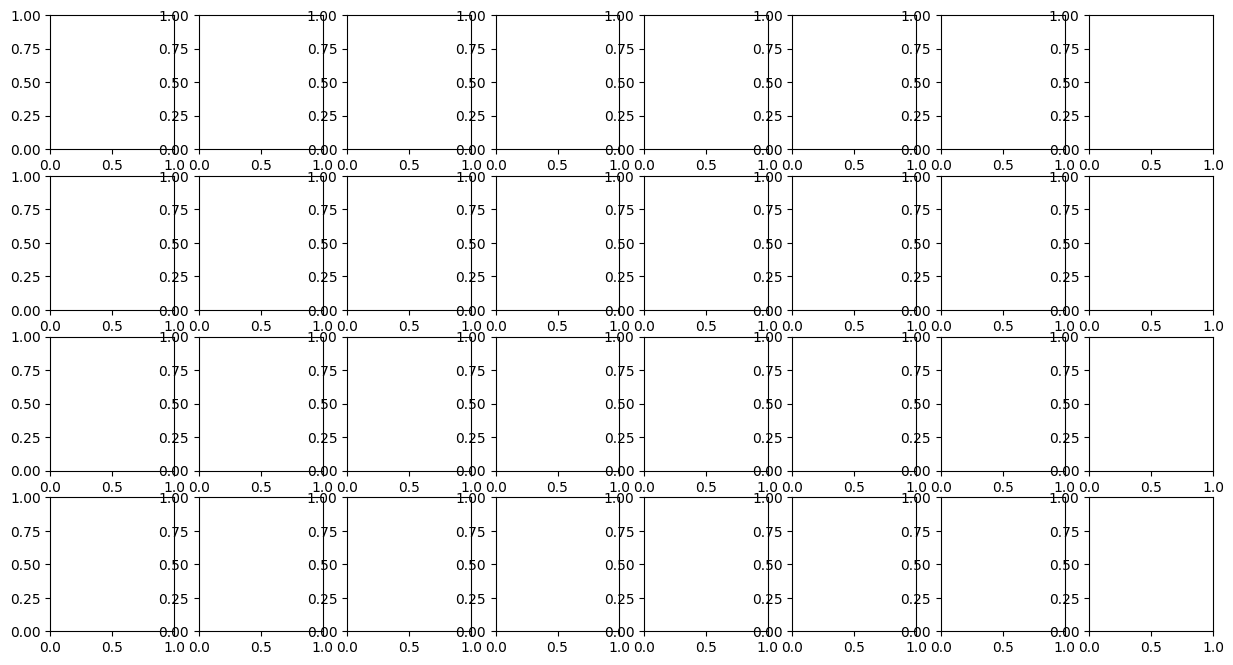

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(15,8))

for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')

plt.show()

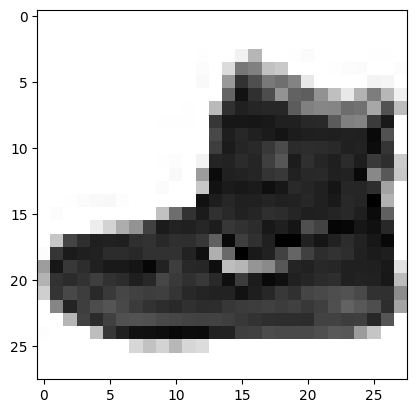

In [ ]:
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [ ]:
#비트겐슈타인 검색해보기